<h1 style="text-align: center;">SMT Challenge 2025 Bayesian Analysis</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to conduct the Bayesian Analysis of the data + the quantification of Aggressiveness</h3>

### Necessary Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

### Helper Functions

In [132]:
home_field_dim = {'QEA': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/310) * (x)**2) + 400, lambda x: -((1/395) * (x)**2) + 400]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/240) * (x)**2) + 384, lambda x: -((1/325) * (x)**2) + 384])
                            },
                    'RZQ': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/380) * (x-60)**2) + 415, lambda x: -((1/340) * (x)**2) + 405]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/310) * (x-60)**2) + 399, lambda x: -((1/270) * (x)**2) + 389])
                            },
                    'YJD': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/300) * (x)**2) + 415, lambda x: -((1/288) * (x)**2) + 417]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/230) * (x)**2) + 399, lambda x: -((1/235) * (x)**2) + 401])
                            }
                }

In [134]:
def stadium_walls(df: pd.DataFrame, home_team: str) -> None:
    """
    Visualizes some form of outline for each team's outfield wall + warning track (QEA, RZQ, YJD)
    I trial and error'd with the exact coefficients in the polynomials for the wall + warning track using the clusters of wall balls and homers

    Arguments: Dataframe, home team's name
    """
    df = df.copy()

    plt.figure(figsize=(8, 8))
    lf_x_values = np.linspace(0, -320)
    lf_foul_line = -lf_x_values
    rf_x_values = np.linspace(0, 320)
    rf_foul_line = rf_x_values

    if home_team == 'QEA':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    elif home_team == 'RZQ':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    else:
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)

    stadium_wall_balls = df[(df['event_code_name'] == 'ball deflection off of wall') & (df['home_team'] == home_team)]

    plt.plot(lf_x_values, lf_foul_line, c='red')
    plt.plot(rf_x_values, rf_foul_line, c='red')
    plt.plot(field_vals, home_run_wall, c='red')
    plt.plot(field_vals, warning_track, c='red')
    # plt.ylim(0, 500)
    plt.legend()
    plt.show()

In [30]:
def distance_needed(df: pd.DataFrame, game_str_id: str):
    """
    Calculates the needed distance between the outfielder's position coordinates and the ball's catch point (where it's caught or where it first bounces)
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## Each outfielder's starting position (player_pos_x, player_pos_y)
    starting_coords = df.iloc[0]
    lf_starting_coords = starting_coords[['field_x_7', 'field_y_7']]
    cf_starting_coords = starting_coords[['field_x_8', 'field_y_8']]
    rf_starting_coords = starting_coords[['field_x_9', 'field_y_9']]

    ## Calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)
    catch_point = df.loc[df['event_code'] == idx_dict[0]].iloc[0][['ball_position_x', 'ball_position_y']]

    play_made_coords = catch_point

    distance_needed_7 = euclidean_distance(lf_starting_coords.iloc[0], lf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])
    distance_needed_8 = euclidean_distance(cf_starting_coords.iloc[0], cf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])
    distance_needed_9 = euclidean_distance(rf_starting_coords.iloc[0], rf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])

    return np.array([distance_needed_7, distance_needed_8, distance_needed_9])

In [5]:
def attempt_metric_creator(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    """
    Creates the column of a metric in df that has multiple columns for each fielder
    Bases it on who made the attempt (which has been talked about how that works) 
    
    Arguments: df: Dataframe, col_name: some metric with columns for each fielder
    """
    df = df.copy()
    df.loc[:, col_name] = np.where(df['player_attempt'] == 7, 
                                           df[f'{col_name}_7'],
                                           np.where(
                                               df['player_attempt'] == 8, 
                                               df[f'{col_name}_8'], 
                                               np.where(
                                                   df['player_attempt'] == 9, 
                                                   df[f'{col_name}_9'],
                                                   np.nan)))
    return df

In [6]:
def info_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Displays information about the dataframe with # of missing values, unique numbers, datatypes, etc.
    
    Arguments: Dataframe
    """
    df = df.copy()
    dtype = df.dtypes
    num_unique = df.T.apply(lambda x: x.nunique(), axis=1)
    nan_total = df.isnull().sum()
    nan_percent = (df.isnull().sum()/df.isnull().count()*100)
    quality_df = pd.concat([nan_total, nan_percent, num_unique, dtype], axis=1, keys=['total_NaNs', 'NaN%', 'num_unique', 'dtypes'])
    display(quality_df)

In [7]:
def metric_into_dict(df: pd.DataFrame, metric) -> dict:
    """
    Creates a dictionary of a metric for each unique play
    
    Arguments: df: Dataframe, metric: one of the helper functions used to calculate some feature
    """
    df = df.copy()
    
    empty_dict = {}
    for i in list(df['game_str_id'].unique()):
        try:
            empty_dict[i] = metric(df, i)
        except Exception as e:
            ## this is a list of plays that cause errors
            print(f"Error play: {i} | Exception: {e}")
            # if i not in messy_plays:
            #     messy_plays.append(i)
            continue
    return empty_dict

In [8]:
def euclidean_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """
    Takes the euclidean distance between two points

    Arguments: (x1, y1), (x2, y2)
    """
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)

In [9]:
def delta_velo_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
    """
    Calculates the change in velocity for each position

    Arguments: df: Dataframe, position: either 7, 8, or 9
    """
    df = df.copy()
    df[f'delta_velo_{position}'] = np.where(df['timestamp'] > df['timestamp'].shift(1), 
                                            df[f'instantaneous_velo_{position}'] - df[f'instantaneous_velo_{position}'].shift(1), 
                                            np.nan)
    return df

In [ ]:
    def stepwise_dist_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
        """
        Calculates the stepwise distance for each position

        Arguments: df: Dataframe, position: either 7, 8, or 9
        """
        df = df.copy()
        df.loc[:, f'stepwise_dist_{position}'] = (
            np.where(df['timestamp'] > df['timestamp'].shift(1), 
                        euclidean_distance(df[f'field_x_{position}'], df[f'field_y_{position}'], 
                                        df[f'field_x_{position}'].shift(1), df[f'field_y_{position}'].shift(1)
                                        ), 
                        np.nan))
        return df

### Loading in the Data

In [224]:
play_data_w_catch_probs = pd.read_csv('catch_probabilities.csv').iloc[:, 1:].copy()
aggressive_data = pd.read_csv('aggressive_data.csv', low_memory=False).iloc[:, 1:].copy()

### Quantifying the Aggressive Binary Target

In [11]:
# play_by_play.loc[:, 'p_catch'] = play_by_play['p_catch'].apply(lambda x: x*100)
# reaction_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['reaction'].mean().to_dict()
# burst_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['burst'].mean().to_dict()
# route_dict = play_by_play.groupby(['difficulty_level', 'direction_angle', 'player_attempt'])['route'].mean().to_dict()
# play_by_play.loc[:, 'avg_reaction'] = play_by_play.apply(lambda x: reaction_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'avg_burst'] = play_by_play.apply(lambda x: burst_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'avg_route'] = play_by_play.apply(lambda x: route_dict.get((x['difficulty_level'], x['direction_angle'], x['player_attempt'])), axis=1)
# play_by_play.loc[:, 'reaction_vs_avg'] = play_by_play['reaction'] - play_by_play['avg_reaction']
# play_by_play.loc[:, 'burst_vs_avg'] = play_by_play['burst'] - play_by_play['avg_burst']
# play_by_play.loc[:, 'route_vs_avg'] = play_by_play['route'] - play_by_play['avg_route']
# play_by_play.loc[:, 'feet_vs_avg'] = play_by_play['reaction_vs_avg'] + play_by_play['burst_vs_avg'] + play_by_play['route_vs_avg']

In [21]:
def catch_point_speed(df: pd.DataFrame, game_str_id: str) -> np.array:
    """
    Finds the speed of the player who made the attempt 0.5 sec before and after the catch
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff']#.iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff']#.iloc[2:]

    time_contact = df.loc[df['event_code'] == 4]['elapsed_timestamp'].iloc[0]
    burst_idx = abs(df.loc[round(df['elapsed_timestamp'], 1) == 1.5]['elapsed_timestamp'] - 1.5).idxmin()
    burst_marker = df.loc[burst_idx]['elapsed_timestamp']
    catch_point = df.loc[(df['event_code'] == 2) & (df['player_position'].isin([7, 8, 9]))]['elapsed_timestamp'].iloc[0]
    
    one_half_sec_before_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point-1.5, 1)]['elapsed_timestamp'] - round(catch_point-1.5, 1)).idxmin()
    if round(catch_point+0.5, 1) > df['elapsed_timestamp'].iloc[-1]:
        one_half_sec_after_catch = df.shape[0]+1
        end_time = 1.5 + (df['elapsed_timestamp'].iloc[-1] - catch_point)
    else:
        one_half_sec_after_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point+0.5, 1)]['elapsed_timestamp'] - round(catch_point+0.5, 1)).idxmin() + 1
        end_time = 2
    df = df.iloc[one_half_sec_before_catch: one_half_sec_after_catch].reset_index(drop=True).copy()

    lf_catch_speed = df[f'stepwise_dist_7'].sum() / end_time
    cf_catch_speed = df[f'stepwise_dist_8'].sum() / end_time
    rf_catch_speed = df[f'stepwise_dist_9'].sum() / end_time

    print([lf_catch_speed, cf_catch_speed, rf_catch_speed])

    return df#np.array([lf_catch_speed, cf_catch_speed, rf_catch_speed])

In [ ]:
catch_point_speed(aggressive_data, 'y2_d067_HKR_RZQ_111')

In [220]:
def visual_trajectory(df: pd.DataFrame, game_str_id: str) -> None:
    """
    Displays the trajectory of any given play from the point of contact to the point the ball is acquired

    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)
    catch_point = df.loc[df['event_code'] == idx_dict[0]].iloc[0]
    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = catch_point['player_position']
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0]

    catch_x = catch_point[f'field_x_{int(nearest_to_catch_pt)}']
    catch_y = catch_point[f'field_y_{int(nearest_to_catch_pt)}']

    if nearest_to_catch_pt == 7:
        player_pos = 'Left Fielder'
    elif nearest_to_catch_pt == 8:
        player_pos = 'Center Fielder'
    elif nearest_to_catch_pt == 9:
        player_pos = 'Right Fielder'

    home_team = df[df['home_team'].notna()]['home_team'].unique()[0]
    if home_team == 'QEA':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    elif home_team == 'RZQ':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    else:
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)

    lf_x_values = np.linspace(0, -320)
    lf_foul_line = -lf_x_values
    rf_x_values = np.linspace(0, 320)
    rf_foul_line = rf_x_values

    plt.figure()
    sns.scatterplot(data=df, x=f'field_x_{int(nearest_to_catch_pt)}', y=f'field_y_{int(nearest_to_catch_pt)}', color='#89CFF0', s=75)
    plt.scatter(catch_x, catch_y, color='#CC3433', s=75, zorder=5, label='Catch Point')
    catch_prob_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'].iloc[0] * 100
    distance_needed_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_needed'].iloc[0]
    distance_to_wall_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_to_wall'].iloc[0]
    opportunity_time_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['opportunity_time'].iloc[0]
    plt.annotate(f'Catch Prob: {catch_prob_text}%', (catch_x, catch_y), textcoords="offset points", xytext=(50, -20), ha='center')
    plt.annotate(f'Distance Needed: {round(distance_needed_text)} ft', (catch_x, catch_y), textcoords="offset points", xytext=(50, -35), ha='center')
    plt.annotate(f'Distance to Wall: {round(distance_to_wall_text, 1)} ft', (catch_x, catch_y), textcoords="offset points", xytext=(50, -50), ha='center')
    plt.annotate(f'Opportunity Time: {round(opportunity_time_text, 1)} sec', (catch_x, catch_y), textcoords="offset points", xytext=(50, -65), ha='center')
    plt.plot(field_vals, home_run_wall, c='black', zorder=0, label='Outfield Wall')
    plt.plot(field_vals, warning_track, c='white', zorder=0)
    plt.plot(lf_x_values, lf_foul_line, c='black', zorder=0)
    plt.plot(rf_x_values, rf_foul_line, c='black', zorder=0)
    plt.fill_between(field_vals, home_run_wall, warning_track, color='#765b4c', alpha=0.5, zorder=0, label='Warning Track Zone')
    plt.xlim(df[f'field_x_{int(nearest_to_catch_pt)}'].min()-5, df[f'field_x_{int(nearest_to_catch_pt)}'].max()+5)
    plt.ylim(df[f'field_y_{int(nearest_to_catch_pt)}'].min()-10, df[f'field_y_{int(nearest_to_catch_pt)}'].max()+8)
    plt.title(f"{player_pos}'s Route on Play {game_str_id}")
    plt.legend()
    plt.show()

    plot_velo_acc(df, game_str_id, int(nearest_to_catch_pt))

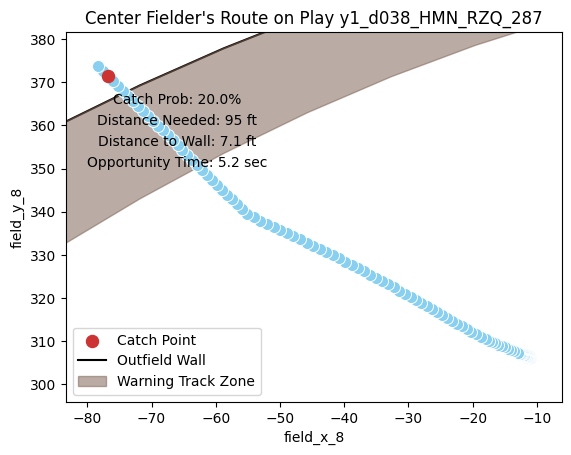

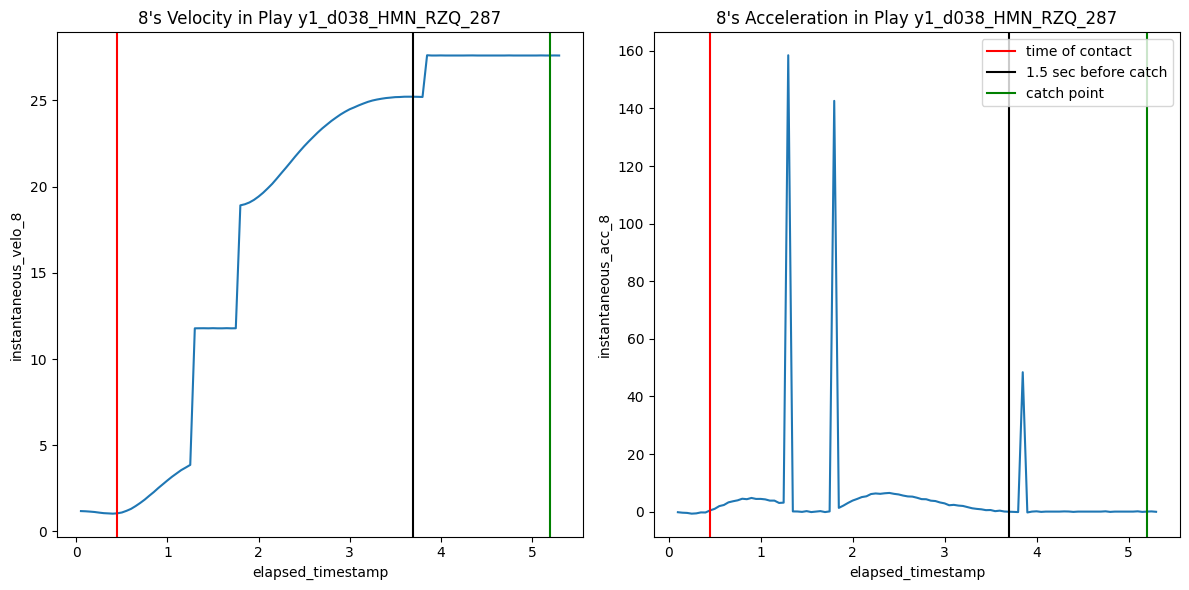

In [223]:
visual_trajectory(aggressive_data, 'y1_d038_HMN_RZQ_287')

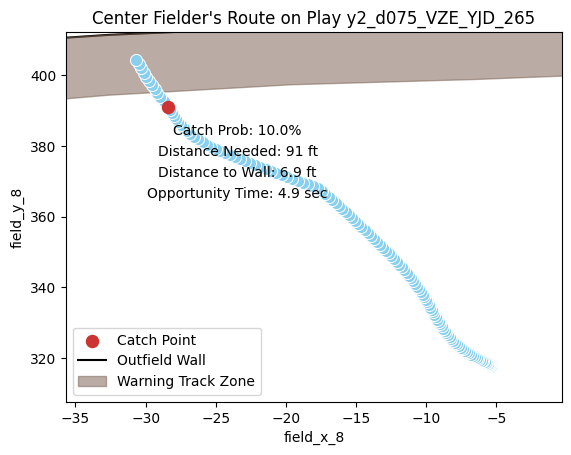

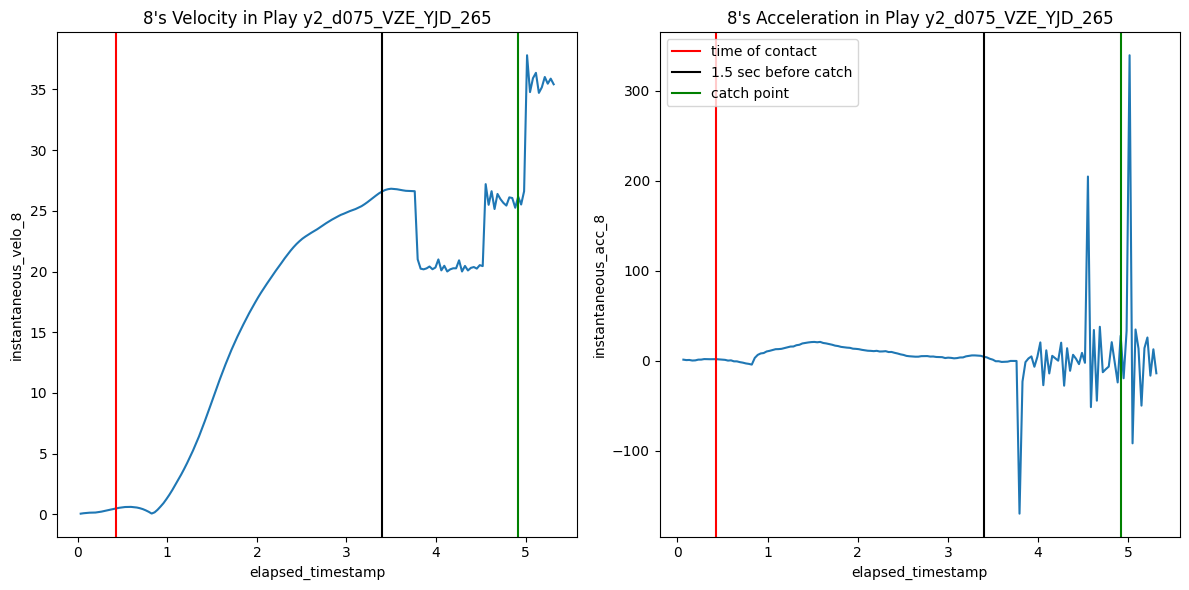

In [221]:
visual_trajectory(aggressive_data, 'y2_d075_VZE_YJD_265')

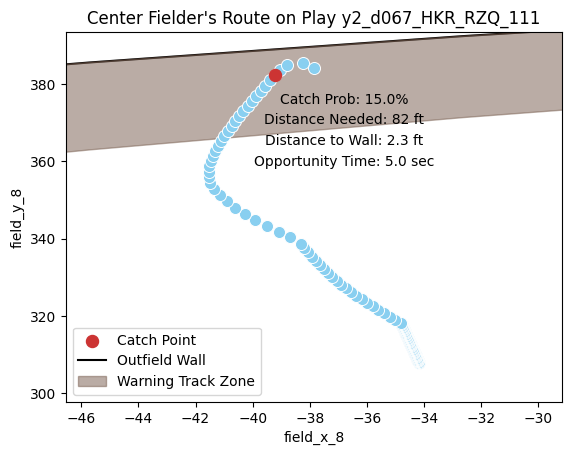

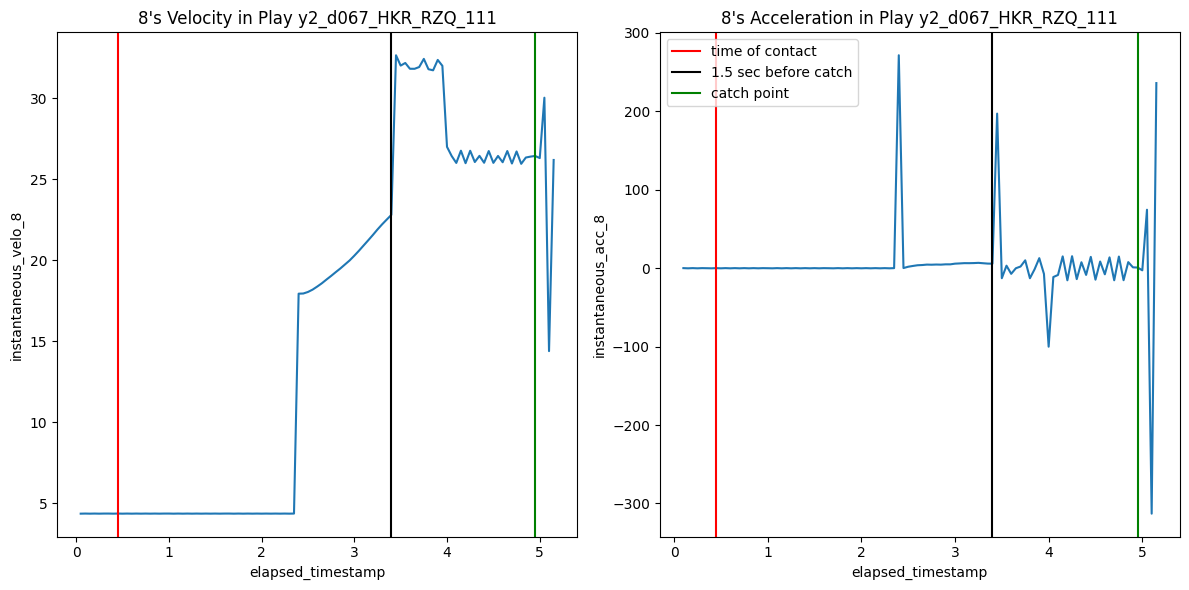

In [222]:
visual_trajectory(aggressive_data, 'y2_d067_HKR_RZQ_111')

In [165]:
def plot_velo_acc(df: pd.DataFrame, game_str_id: str, position: int) -> None:
    """
    Finds the speed of the player who made the attempt 0.5 sec before and after the catch
    
    Arguments: df: Dataframe, game_str_id: game_str_id, position: outfielder code (7, 8, or 9)
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff'].iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff'].iloc[2:]

    time_contact = df.loc[df['event_code'] == 4]['elapsed_timestamp'].iloc[0]
    catch_point = df.loc[(df['event_code'] == 2) & (df['player_position'].isin([7, 8, 9]))]['elapsed_timestamp'].iloc[0]
    one_half_sec_before_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point-1.5, 1)]['elapsed_timestamp'] - round(catch_point-1.5, 1)).idxmin()
    one_half_s_marker = df.loc[one_half_sec_before_catch]['elapsed_timestamp']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    sns.lineplot(data=df.iloc[1:], x='elapsed_timestamp', y=f'instantaneous_velo_{position}', ax=ax1)
    ax1.axvline(x=time_contact, label='time of contact', c='red')
    ax1.axvline(x=one_half_s_marker, label='1.5 sec before catch', c='black')
    ax1.axvline(x=catch_point, label='catch point', c='green')
    ax1.set_title(f"{position}'s Velocity in Play {game_str_id}")
    sns.lineplot(data=df.iloc[2:], x='elapsed_timestamp', y=f'instantaneous_acc_{position}', ax=ax2)
    ax2.axvline(x=time_contact, label='time of contact', c='red')
    ax2.axvline(x=one_half_s_marker, label='1.5 sec before catch', c='black')
    ax2.axvline(x=catch_point, label='catch point', c='green')
    ax2.set_title(f"{position}'s Acceleration in Play {game_str_id}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [135]:
aggressive_data

,game_str_id,timestamp,at_bat,play_per_game,player_position,player_position_name,event_code,event_code_name,field_x_7,field_y_7,field_x_8,field_y_8,field_x_9,field_y_9,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,timestamp_diff,elapsed_timestamp
0,y1_d001_CGA_QEA_4,83.599,2,4.0,1.0,pitcher,1.0,pitch,-133.3230,230.9340,-32.4459,288.7827,96.0153,262.4820,-1.573368,54.88170,5.69139,QEA,CGA,year_1,day_001,0.00,0.00
1,y1_d001_CGA_QEA_4,83.649,NaN,NaN,NaN,NaN,NaN,NaN,-133.3344,230.9436,-32.4774,288.7269,96.0027,262.4826,-1.348383,48.44760,5.48709,NaN,NaN,NaN,NaN,0.05,0.05
2,y1_d001_CGA_QEA_4,83.699,NaN,NaN,NaN,NaN,NaN,NaN,-133.3488,230.9529,-32.5086,288.6756,95.9871,262.4850,-1.138191,42.06180,5.23302,NaN,NaN,NaN,NaN,0.05,0.10
3,y1_d001_CGA_QEA_4,83.749,NaN,NaN,NaN,NaN,NaN,NaN,-133.3656,230.9622,-32.5386,288.6294,95.9688,262.4889,-0.942786,35.72490,4.92924,NaN,NaN,NaN,NaN,0.05,0.15
4,y1_d001_CGA_QEA_4,83.799,NaN,NaN,NaN,NaN,NaN,NaN,-133.3851,230.9706,-32.5665,288.5883,95.9475,262.4937,-0.762171,29.43678,4.57575,NaN,NaN,NaN,NaN,0.05,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910120,y2_d098_YJD_RZQ_259,9634.213,NaN,NaN,NaN,NaN,NaN,NaN,-186.2337,222.2595,-56.4387,291.1860,101.1678,260.0562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,4.10
910121,y2_d098_YJD_RZQ_259,9634.263,NaN,NaN,NaN,NaN,NaN,NaN,-187.0059,222.3615,-56.8728,290.7726,100.9851,259.9332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,4.15
910122,y2_d098_YJD_RZQ_259,9634.313,NaN,NaN,NaN,NaN,NaN,NaN,-187.7781,222.4635,-57.3066,290.3583,100.8021,259.8099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,4.20
910123,y2_d098_YJD_RZQ_259,9634.363,NaN,NaN,NaN,NaN,NaN,NaN,-188.5506,222.5655,-57.7401,289.9434,100.6188,259.6863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,4.25


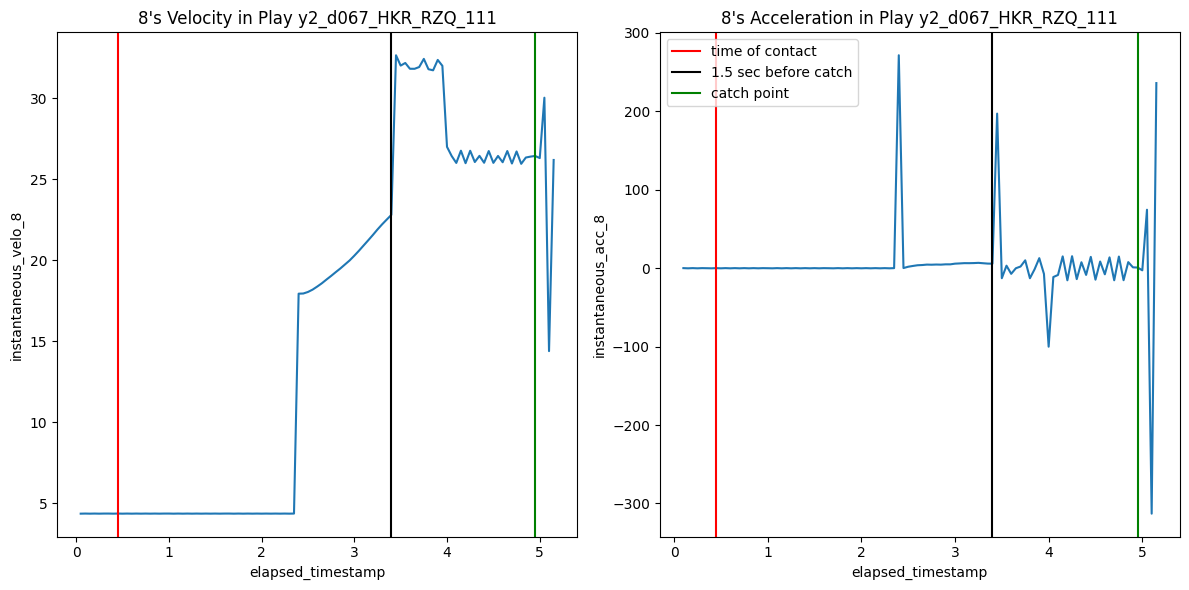

In [222]:
plot_velo_acc(aggressive_data, 'y2_d067_HKR_RZQ_111', 8)

In [ ]:
catch_point_speed_dict = metric_into_dict(aggressive_data, catch_point_speed)
catch_point_speed_df = pd.DataFrame.from_dict(catch_point_speed_dict, orient='index', columns=['catch_speed_7', 'catch_speed_8', 'catch_speed_9']).reset_index(names=['game_str_id']).copy()

In [195]:
play_data_w_catch_probs = play_data_w_catch_probs.merge(catch_point_speed_df, on='game_str_id', how='left').copy()

In [201]:
catch_speeds = play_data_w_catch_probs[['catch_speed_7', 'catch_speed_8', 'catch_speed_9']]
sprint_speeds = play_data_w_catch_probs[['sprint_speed_7', 'sprint_speed_8', 'sprint_speed_9']].map(lambda x: np.nan if round(x) == 0 else x)
play_data_w_catch_probs[['catch_speed_ratio_7', 'catch_speed_ratio_8', 'catch_speed_ratio_9']] = catch_speeds.values / sprint_speeds.values

In [205]:
play_data_w_catch_probs = attempt_metric_creator(play_data_w_catch_probs, 'catch_speed_ratio').copy()

In [210]:
play_data_w_catch_probs[(play_data_w_catch_probs['difficulty_level'] == '5 Star') 
                        & ((play_data_w_catch_probs['is_out_catch'] == 1) | (play_data_w_catch_probs['whiffed_catch'] == 1))
                        & (play_data_w_catch_probs['catch_speed_ratio']>=1)
                        ].sort_values(by='p_catch')

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level,catch_speed_7,catch_speed_8,catch_speed_9,catch_speed_ratio_7,catch_speed_ratio_8,catch_speed_ratio_9,catch_speed_ratio
5303,y2_d098_YJD_RZQ_146,31.674520,43.096223,17.088897,3.050,2.600,Back Right,In Left,In Left,88.069567,50.588403,168.929430,18.480465,21.880673,10.438544,148.605086,29.680839,96.417483,1.0,0,NaN,8.0,8.0,0.0,4.993828,10.565666,2.709817,25.861166,32.851714,14.231103,31.346052,43.907987,16.284059,146.0,y2_d098_YJD_RZQ,0.0,YJD-0185,YJD-0019,YJD-0397,50.588403,43.096223,In Left,21.880673,10.565666,32.851714,43.907987,y2,YJD,RZQ,0.10,0,5 Star,21.371530,22.389359,12.042878,1.156439,1.023248,1.153693,1.023248
1241,y1_d049_JZK_RZQ_164,28.001224,55.970734,69.406501,4.400,3.950,Back Right,Back Right,Back,267.188456,130.127747,78.799234,12.396078,17.755103,24.005946,19.564526,36.614927,103.794640,1.0,0,NaN,9.0,9.0,0.0,3.618473,7.070598,5.420746,7.972971,24.404565,29.470073,9.793232,28.534147,35.757574,164.0,y1_d049_JZK_RZQ,0.0,JZK-1207,JZK-1781,JZK-1356,78.799234,69.406501,Back,24.005946,5.420746,29.470073,35.757574,y1,JZK,RZQ,0.10,0,5 Star,14.384926,20.115719,25.865050,1.160442,1.132954,1.077443,1.077443
1591,y1_d057_OXG_QEA_354,80.122507,11.672841,1.434719,4.600,4.200,In Left,In Left,In Left,83.898672,209.629964,355.764744,22.483437,4.003454,0.823619,11.453336,41.866335,87.993939,1.0,0,NaN,7.0,7.0,0.0,12.671551,1.364406,1.236776,31.130547,4.384824,0.441803,42.506219,4.803394,0.563161,354.0,y1_d057_OXG_QEA,0.0,OXG-0018,OXG-0085,OXG-0134,83.898672,80.122507,In Left,22.483437,12.671551,31.130547,42.506219,y1,OXG,QEA,0.10,0,5 Star,25.325409,4.295424,0.099096,1.126403,1.072930,0.120318,1.126403
4835,y2_d075_VZE_YJD_265,43.126469,77.889496,58.186403,4.917,4.488,Back Right,Back,Back Left,185.090908,91.051512,228.965854,12.789485,24.740314,16.196216,6.946850,42.482536,98.940939,1.0,1,4.615620,8.0,8.0,0.0,5.112066,2.851667,4.998708,14.800831,29.535645,21.742491,16.174966,32.443235,25.344821,265.0,y2_d075_VZE_YJD,0.0,VZE-1724,VZE-2346,VZE-1476,91.051512,77.889496,Back,24.740314,2.851667,29.535645,32.443235,y2,VZE,YJD,0.10,0,5 Star,14.462817,30.311725,17.150063,1.130837,1.225196,1.058893,1.225196
2783,y1_d095_XAX_QEA_98,35.554172,61.416949,34.762091,3.700,3.250,Back Right,In,In Left,118.118295,64.831639,148.404894,16.593039,25.632137,14.890279,145.207973,58.708049,75.584744,1.0,0,NaN,8.0,8.0,0.0,5.680718,13.950287,6.485386,19.364453,30.650967,18.885388,24.505709,45.802207,25.769622,98.0,y1_d095_XAX_QEA,1.0,QEA-0369,QEA-0365,QEA-0182,64.831639,61.416949,In,25.632137,13.950287,30.650967,45.802207,y1,XAX,QEA,0.15,0,5 Star,18.309698,27.050343,18.250184,1.103457,1.055329,1.225644,1.055329
4636,y2_d067_HKR_RZQ_111,47.010263,73.284892,45.420722,4.950,4.500,Back Right,Back,Back Left,184.103973,82.492493,199.086874,13.044698,28.222682,12.962992,2.318308,36.462974,103.500961,1.0,1,-0.517491,8.0,8.0,0.0,5.714704,6.542035,12.716828,16.255547,15.995787,16.532274,21.261924,23.457076,16.113305,111.0,y2_d067_HKR_RZQ,1.0,RZQ-0143,RZQ-0274,RZQ-0346,82.492493,73.284892,Back,28.222682,6.542035,15.995787,23.457076,y2,HKR,RZQ,0.15,0,5 Star,15.722065,29.494683,11.588726,1.205246,1.045070,0.893985,1.045070
4201,y2_d050_DYE_RZQ_17,8.344355,15.333405,28.755257,2.700,2.300,In Right,In Right,In,242.825325,140.975901,39.094352,6.413033,8.304545,17.376932,111.646381,98.0934

### Bayesian Analysis

In [225]:
play_data_w_catch_probs

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level
0,y1_d001_CGA_QEA_240,10.851247,9.086522,2.155856,3.20,2.80,In Left,In Left,Back Left,12.824938,153.616141,242.682589,5.718944,3.534968,0.970684,69.884915,45.078858,94.377383,1.0,0,NaN,7.0,7.0,0.0,2.081028,3.788840,1.181984,8.322920,5.490593,1.015666,10.253843,9.387799,1.651421,240.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,12.824938,10.851247,In Left,5.718944,2.081028,8.322920,10.253843,y1,CGA,QEA,0.95,1,1 Star
1,y1_d001_CGA_QEA_256,40.752090,51.366908,41.555113,3.70,3.25,In Right,In Right,In Left,146.361479,71.571528,93.250419,16.544438,24.097861,16.662136,157.590665,39.835271,71.875289,0.0,0,NaN,8.0,8.0,0.0,6.087127,4.788836,5.478716,23.904072,29.014366,25.389299,29.183446,34.206121,30.930725,256.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,71.571528,51.366908,In Right,24.097861,4.788836,29.014366,34.206121,y1,CGA,QEA,0.10,0,5 Star
2,y1_d001_CGA_QEA_195,5.931540,17.049194,19.783084,2.45,2.05,In Right,In Right,In,214.763726,173.878553,113.523389,3.633669,11.467247,15.454587,197.832670,56.395341,70.778037,0.0,0,NaN,9.0,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,195.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,113.523389,19.783084,In,15.454587,NaN,NaN,NaN,y1,CGA,QEA,0.00,0,5 Star
3,y1_d001_CGA_QEA_262,22.839094,5.672331,2.289652,2.50,2.05,In,In Left,In Left,80.313315,165.692225,232.381521,15.870060,3.218863,1.545573,127.607913,52.200602,90.253353,0.0,0,NaN,7.0,7.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,262.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,80.313315,22.839094,In,15.870060,NaN,NaN,NaN,y1,CGA,QEA,0.00,0,5 Star
4,y1_d001_CGA_QEA_274,16.153562,56.441888,33.625889,5.10,4.65,In Right,In Right,Back Left,215.824188,89.689035,29.527484,3.972489,16.521860,12.682216,90.206290,39.664283,73.064776,1.0,0,NaN,9.0,9.0,0.0,2.245274,4.998017,5.315608,6.133556,23.692122,17.504153,7.464141,28.981189,21.710668,274.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,29.527484,33.625889,Back Left,12.682216,5.315608,17.504153,21.710668,y1,CGA,QEA,0.95,1,1 Star
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5307,y2_d098_YJD_RZQ_31,58.934871,43.425153,51.200365,5.55,5.10,In Left,In Left,In Left,58.501942,191.678279,297.083654,17.003829,11.716270,14.456756,12.443687,47.492657,83.093814,1.0,0,NaN,7.0,7.0,0.0,4.961152,6.299032,2.449183,23.929984,9.626690,12.719698,28.841153,15.513497,14.202365,31.0,y2_d098_YJD_RZQ,0.0,YJD-0185,YJD-0019,YJD-0397,58.501942,58.934871,In Left,17.003829,4.961152,23.929984,28.841153,y2,YJD,RZQ,0.95,1,1 Star
5308,y2_d098_YJD_RZQ_27,15.630649,54.975692,64.723286,4.10,3.65,Back Right,In Right,In Left,191.243692,92.040877,64.570861,5.352801,18.570224,25.881714,116.428579,43.966029,76.873693,1.0,0,NaN,9.0,9.0,0.0,3.698580,8.670381,4.644516,7.849271,26.731749,30.475450,11.449862,35.014613,35.615767,27.0,y2_d098_YJD_RZQ,0.0,YJD-0185,YJD-0019,YJD-0397,64.570861,64.723286,In Left,25.881714,4.644516,30.475450,35.615767,y2,YJD,RZQ,0.55,1,3 Star
5309,y2_d098_YJD_RZQ_13,32.003407,32.533982,32.870219,3.10,2.65,In Right,In,In Left,142.573368,121.095811,141.371753,17.527813,19.833817,16.301919,191.836656,55.636264,70.365950,0.0,0,NaN,8.0,8.0,0.0,5.803973,3.896792,7.0008